# 02 — Calibración de severidad de M1 y adimensionalización

Tareas **T13** (calibración) y **T17** (adimensionalización).

**Severidad** = qué tan equivocado está el modelo simple (empotramiento ideal) frente a los datos generados con M1 (soporte flexible). La medimos como el **sesgo en E** que comete quien invierte la frecuencia ω₁ con el modelo ideal. Como ω² ∝ E:

  sesgo_E = (ω₁ᴹ¹ / ω₁ᴹ⁰)² − 1

También reportamos la diferencia L2 relativa entre las formas modales y el **ΔL equivalente**: cuánto más larga tendría que ser una viga ideal para vibrar igual.

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pinn_mems import Soporte, Viga, resolver_modos
from pinn_mems.adimensional import Escalas
from pinn_mems.severidad import kappa_para_sesgo, severidad

COLORES = ["#2a78d6", "#eb6834", "#1baf7a"]
plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e6e6e3", "grid.linewidth": 0.6,
    "lines.linewidth": 2, "figure.dpi": 110,
})
viga = Viga(E=70e9, L=300e-6, b=28e-6, h=2.743e-6, rho=2200.0)  # RM 8096
ESTRUCTURAS = ["voladizo", "biempotrada"]

## 1. Los 6 puntos de severidad

Los sesgos objetivo en E son **1, 2.5, 5, 10, 15 y 25%**:

- **s3 = 5%**: el error sistemático por el soporte que reporta la literatura de M-TEST (cifra pendiente de verificar contra la fuente).
- **s5 = 15%**: en L = 300 µm equivale a **ΔL ≈ 12.4 µm**, justo el orden del ajuste exploratorio a los datos del NIST (ΔL ≈ 12–13 µm). Es decir, el nivel "realista" según los datos reales.
- s1 y s6 cubren los extremos: casi ideal y fuerte.

Por ahora solo se ablanda el resorte rotacional (κ_u = ∞). Falta fijar κ_u con los valores de Kobrinsky et al. (2000); ver la sección 3.

In [2]:
tabla = pd.read_csv("../datos/sinteticos/calibracion.csv").query("generador == 'M1'")
vista = tabla.assign(
    sesgo_E=lambda d: (100 * d.sesgo_E).round(2),
    diferencia_forma=lambda d: (100 * d.diferencia_forma).round(2),
    delta_L_um=lambda d: (1e6 * d.delta_L).round(2),
    kappa_theta=lambda d: d.kappa_theta.round(1),
)[["nombre", "kappa_theta", "sesgo_E", "diferencia_forma", "delta_L_um"]]
vista.columns = ["config", "κ_θ", "sesgo E (%)", "dif. forma (%)", "ΔL (µm)"]
vista

,config,κ_θ,sesgo E (%),dif. forma (%),ΔL (µm)
0,m1_voladizo_s1,396.1,-1.0,0.62,0.75
1,m1_voladizo_s2,156.1,-2.5,1.53,1.90
2,m1_voladizo_s3,76.1,-5.0,2.96,3.87
3,m1_voladizo_s4,36.1,-10.0,5.56,8.01
4,m1_voladizo_s5,22.8,-15.0,7.87,12.44
5,m1_voladizo_s6,12.1,-25.0,11.79,22.37
8,m1_biempotrada_s1,790.3,-1.0,0.45,0.75
9,m1_biempotrada_s2,310.3,-2.5,1.12,1.90
10,m1_biempotrada_s3,150.3,-5.0,2.21,3.87
11,m1_biempotrada_s4,70.3,-10.0,4.31,8.01


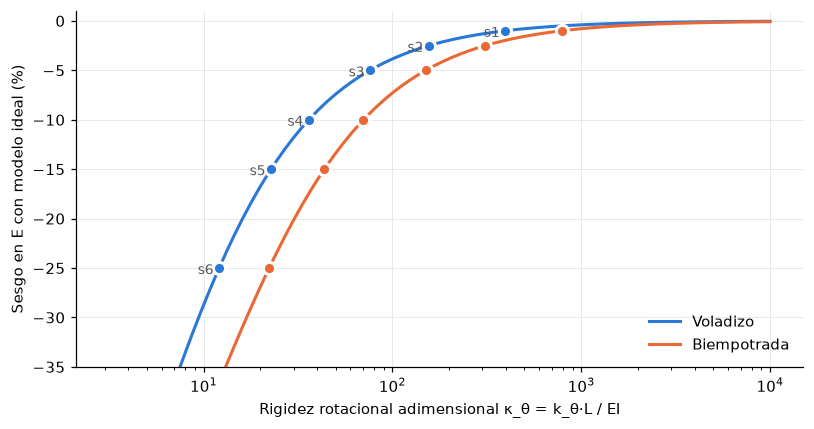

In [3]:
kappas = np.logspace(0.5, 4, 80)
fig, eje = plt.subplots(figsize=(7.5, 4))
for i, est in enumerate(ESTRUCTURAS):
    curva = [severidad(viga, est, Soporte(kappa_theta=k)).sesgo_E for k in kappas]
    eje.semilogx(kappas, 100 * np.array(curva), color=COLORES[i], label=est.capitalize())
    puntos = tabla[tabla.estructura == est]
    eje.plot(puntos.kappa_theta, 100 * puntos.sesgo_E, "o", color=COLORES[i], markersize=8,
             markeredgecolor="white", markeredgewidth=2)
for _, fila in tabla[tabla.estructura == "voladizo"].iterrows():
    eje.annotate(fila.nivel, (fila.kappa_theta, 100 * fila.sesgo_E), textcoords="offset points",
                 xytext=(-14, -4), color="#555", fontsize=9)
eje.set_xlabel("Rigidez rotacional adimensional κ_θ = k_θ·L / EI")
eje.set_ylabel("Sesgo en E con modelo ideal (%)")
eje.set_ylim(-35, 1)
eje.legend(frameon=False, loc="lower right")
fig.tight_layout()

### ¿Se ve el error en la forma modal?

La forma modal cambia mucho menos que la frecuencia. Con 2% de ruido en las formas (el valor por defecto), en **s1 y s2** la diferencia de forma queda por debajo del ruido: un método que solo mire la forma casi no podrá distinguir M1 de M0. Desde s4 la diferencia ya es claramente mayor que el ruido.

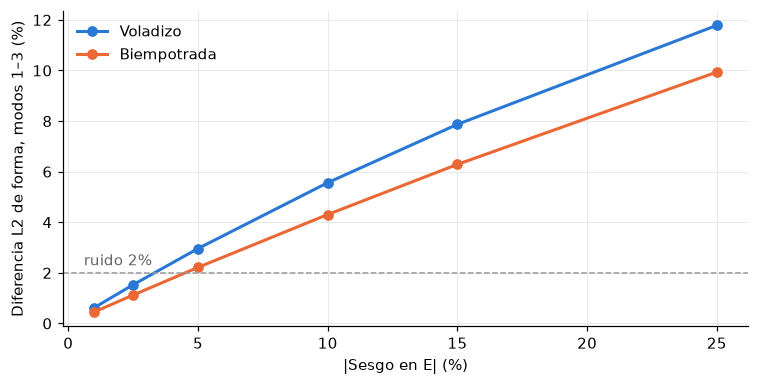

In [4]:
fig, eje = plt.subplots(figsize=(7, 3.6))
for i, est in enumerate(ESTRUCTURAS):
    p = tabla[tabla.estructura == est]
    eje.plot(-100 * p.sesgo_E, 100 * p.diferencia_forma, "o-", color=COLORES[i],
             markersize=6, label=est.capitalize())
eje.axhline(2, color="#999", linestyle="--", linewidth=1)
eje.text(0.6, 2.3, "ruido 2%", color="#666")
eje.set_xlabel("|Sesgo en E| (%)")
eje.set_ylabel("Diferencia L2 de forma, modos 1–3 (%)")
eje.legend(frameon=False)
fig.tight_layout()

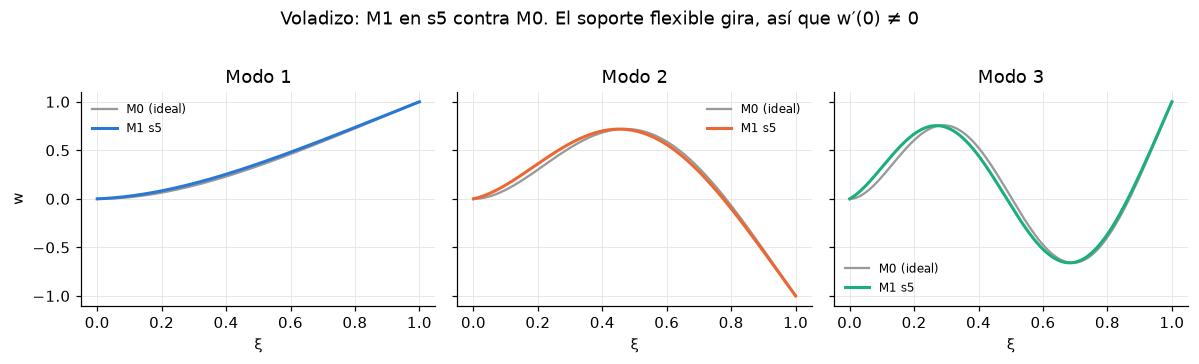

In [5]:
xi = np.linspace(0, 1, 300)
s5 = Soporte(kappa_theta=float(tabla.query("nombre == 'm1_voladizo_s5'").kappa_theta.iloc[0]))
w0 = resolver_modos(viga, "voladizo").forma(xi)
w1 = resolver_modos(viga, "voladizo", s5).forma(xi)
fig, ejes = plt.subplots(1, 3, figsize=(11, 3.2), sharey=True)
for m, eje in enumerate(ejes):
    eje.plot(xi, w0[m], color="#999", linewidth=1.5, label="M0 (ideal)")
    eje.plot(xi, w1[m], color=COLORES[m], label="M1 s5")
    eje.set_title(f"Modo {m + 1}")
    eje.set_xlabel("ξ")
    eje.legend(frameon=False, fontsize=8)
ejes[0].set_ylabel("w")
fig.suptitle("Voladizo: M1 en s5 contra M0. El soporte flexible gira, así que w′(0) ≠ 0", y=1.02)
fig.tight_layout()

## 2. El mismo anclaje en vigas de distinta longitud

El NIST mide voladizos de 200, 300 y 400 µm, y el E aparente sube con L. Su ajuste exploratorio fue `E(L) = E_real·(L/(L+ΔL))⁴`.

Si el anclaje es el mismo para todas las vigas (k_θ físico fijo, en N·m/rad), su rigidez adimensional κ_θ = k_θ·L/EI crece con L. Las vigas largas "sienten" menos el anclaje. Aquí fijamos el k_θ físico de s5 en L = 300 µm y calculamos el E aparente a otras longitudes: M1 reproduce la forma de la curva del NIST con un ΔL casi constante.

k_θ físico de s5: 2.559e-07 N·m/rad


ΔL equivalente: 11.81–12.67 µm (casi constante)


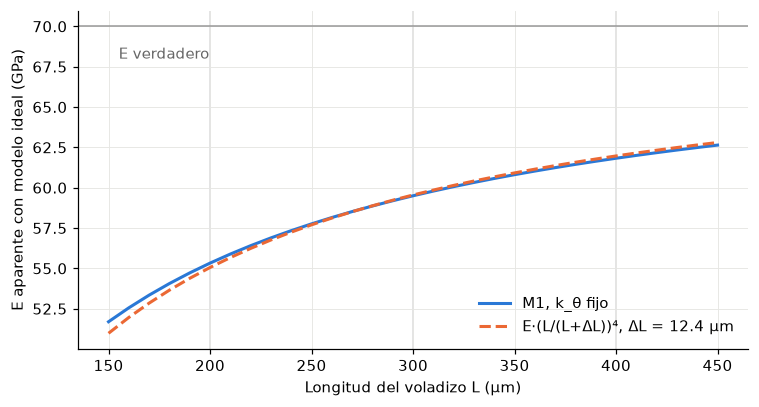

In [6]:
esc = Escalas.desde_viga(viga)
k_theta_fisico, _ = esc.desde_soporte(s5)
print(f"k_θ físico de s5: {k_theta_fisico:.3e} N·m/rad")

longitudes = np.linspace(150e-6, 450e-6, 31)
E_aparente, delta_L = [], []
for L in longitudes:
    v = Viga(**{**viga.__dict__, "L": L})
    sev = severidad(v, "voladizo", Soporte.desde_rigideces(v, k_theta_fisico, math.inf))
    E_aparente.append(viga.E * (1 + sev.sesgo_E))
    delta_L.append(sev.delta_L)
dl = np.mean(delta_L)
print(f"ΔL equivalente: {1e6 * min(delta_L):.2f}–{1e6 * max(delta_L):.2f} µm (casi constante)")

fig, eje = plt.subplots(figsize=(7, 3.8))
eje.plot(1e6 * longitudes, np.array(E_aparente) / 1e9, color=COLORES[0], label="M1, k_θ fijo")
eje.plot(1e6 * longitudes, viga.E * (longitudes / (longitudes + dl)) ** 4 / 1e9, "--",
         color=COLORES[1], label=f"E·(L/(L+ΔL))⁴, ΔL = {1e6 * dl:.1f} µm")
eje.axhline(viga.E / 1e9, color="#999", linewidth=1)
eje.text(155, viga.E / 1e9 - 2, "E verdadero", color="#666")
for L in (200, 300, 400):
    eje.axvline(L, color="#ddd", linewidth=1, zorder=0)
eje.set_xlabel("Longitud del voladizo L (µm)")
eje.set_ylabel("E aparente con modelo ideal (GPa)")
eje.legend(frameon=False, loc="lower right")
fig.tight_layout()

## 3. ¿Y el resorte traslacional κ_u?

En la calibración κ_u = ∞. La tabla muestra cuánto cambia el sesgo de s3 si el soporte también se desplaza. En el voladizo el efecto es pequeño mientras κ_u ≳ 10³. En la biempotrada, κ_u < 10⁴ ya domina el sesgo. **Pendiente:** fijar κ_u, o la razón κ_u/κ_θ, con los valores de Kobrinsky et al. (2000) y recalibrar con `scripts/calibrar_severidad.py`.

In [7]:
filas = []
for est in ESTRUCTURAS:
    k3 = float(tabla.query(f"nombre == 'm1_{est}_s3'").kappa_theta.iloc[0])
    for ku in [math.inf, 1e5, 1e4, 1e3]:
        s = severidad(viga, est, Soporte(kappa_theta=k3, kappa_u=ku))
        filas.append({"estructura": est, "κ_u": ku, "sesgo E (%)": round(100 * s.sesgo_E, 2)})
pd.DataFrame(filas).pivot(index="κ_u", columns="estructura", values="sesgo E (%)").sort_index(ascending=False)

estructura,biempotrada,voladizo
κ_u,,
inf,-5.00,-5.00
100000.0,-5.16,-5.01
10000.0,-6.56,-5.07
1000.0,-19.29,-5.69


## 4. Adimensionalización (T17)

La PINN no puede entrenar con unidades SI: en una viga MEMS conviven 10⁻¹⁸ (I, en m⁴) y 10¹¹ (E, en Pa). Con

  ξ = x/L,  W = w/h,  M̂ = M·L²/(EI·h),  λ = ω²ρA·L⁴/EI,  n = N·L²/EI,  κ_θ = k_θ·L/EI,  κ_u = k_u·L³/EI

la forma mixta de la PINN queda sin constantes físicas:

  r₁: M̂ − W″ = 0  r₂: M̂″ − n·W″ − λ·W = 0

Todo se convierte con `pinn_mems.adimensional.Escalas` (o `escalar()` / `desescalar()`). El eigensolver usa los mismos grupos por dentro.

In [8]:
modos = resolver_modos(viga, "voladizo", s5)
w_punta = 50e-9   # amplitud típica de vibración medida, 50 nm
M_tipico = viga.EI * w_punta / viga.L**2
si = {
    "I (m⁴)": viga.I, "E (Pa)": viga.E, "ρA (kg/m)": viga.rho * viga.A,
    "ω₁ (rad/s)": modos.omega[0], "k_θ (N·m/rad)": k_theta_fisico,
    "w (m)": w_punta, "M (N·m)": M_tipico,
}
adim = {
    "λ₁": esc.a_lambda(modos.omega[0]), "κ_θ": s5.kappa_theta,
    "W": esc.a_W(w_punta), "M̂": esc.a_M(M_tipico), "θ = E/E_ref": 1.0,
}
print("Unidades SI:  ", "  ".join(f"{k} = {v:.1e}" for k, v in si.items()))
print(f"  → abarcan {np.log10(max(si.values()) / min(si.values())):.0f} órdenes de magnitud")
print("Adimensional: ", "  ".join(f"{k} = {v:.3g}" for k, v in adim.items()))
print(f"  → abarcan {np.log10(max(adim.values()) / min(adim.values())):.1f} órdenes de magnitud")

Unidades SI:   I (m⁴) = 4.8e-23  E (Pa) = 7.0e+10  ρA (kg/m) = 1.7e-07  ω₁ (rad/s) = 1.6e+05  k_θ (N·m/rad) = 2.6e-07  w (m) = 5.0e-08  M (N·m) = 1.9e-12
  → abarcan 33 órdenes de magnitud
Adimensional:  λ₁ = 10.5  κ_θ = 22.8  W = 0.0182  M̂ = 0.0182  θ = E/E_ref = 1
  → abarcan 3.1 órdenes de magnitud


### Rangos físicos de los grupos

λ es el eigenvalor del problema adimensional y **no depende de L, b, h ni del material**: solo de n, κ_θ y κ_u. Para los voladizos del NIST, n = 0 (extremo libre, sin carga axial) y κ_θ ≈ 10–400 según la severidad.

Para las biempotradas, n = 12·ε_r·L²/h² depende de la deformación residual ε_r. Abajo se usa un rango supuesto de |ε_r| ≤ 2×10⁻⁴; **pendiente de confirmar con las Tablas RS1/RS9 del NIST (T07)**.

In [9]:
for L_um in (200, 300, 400, 600, 750):
    L = L_um * 1e-6
    n_max = 12 * 2e-4 * L**2 / viga.h**2
    print(f"L = {L_um} µm: n ∈ [−{n_max:.0f}, {n_max:.0f}]  (pandeo de la biempotrada en n = −4π² ≈ −39.5)")
lams = {est: resolver_modos(viga, est).lam for est in ESTRUCTURAS}
print("λ con soporte ideal y n = 0:", {k: np.round(v, 1) for k, v in lams.items()})

L = 200 µm: n ∈ [−13, 13]  (pandeo de la biempotrada en n = −4π² ≈ −39.5)
L = 300 µm: n ∈ [−29, 29]  (pandeo de la biempotrada en n = −4π² ≈ −39.5)
L = 400 µm: n ∈ [−51, 51]  (pandeo de la biempotrada en n = −4π² ≈ −39.5)
L = 600 µm: n ∈ [−115, 115]  (pandeo de la biempotrada en n = −4π² ≈ −39.5)
L = 750 µm: n ∈ [−179, 179]  (pandeo de la biempotrada en n = −4π² ≈ −39.5)
λ con soporte ideal y n = 0: {'voladizo': array([  12.4,  485.5, 3806.5]), 'biempotrada': array([  500.6,  3803.5, 14617.6])}


## Pendientes

- Fijar κ_u (o κ_u/κ_θ) con Kobrinsky et al. (2000) y recalibrar (`scripts/calibrar_severidad.py`).
- Verificar la cifra de 5% de M-TEST contra la fuente original (s3).
- Confirmar el rango de ε_r con las Tablas RS1/RS9 del NIST (T07).
- Con los valores por voladizo de la Fig. YM6 (T06), comparar el ΔL de s5 con un ajuste más sólido que el de tres promedios.

Los generadores M2 y M3 están en `03_generadores_m2_m3.ipynb`.